In [7]:
from FormUtils import  pyForm, capture_physics_expr

In [8]:
%%pyForm ee_to_mumu_massless

* Process: e+ e- -> mu+ mu-

#include amplitude.inc

* Kinematic variables
Symbols s, t, u;

* Physical constants
Symbols e, pi, alpha;

* Three momenta ratio in CM
Symbols pfInOutRatio;



Local M = (e^2 / s) * (VB(i1, p2, 0) * g(i1, i2, j1) * U(i2, p1, 0)) * (UB(i3, p3, 0) * g(i3, i4, j1) * V(i4, p4, 0));
#call squareamplitude(M, Msq)

.sort
trace4, 1;
trace4, 2;
.sort
contract;
Print Msq;
.sort

* Physics & Normalization
id e^4 = 16 * pi^2 * alpha^2;
* Spin averaging (1/2 * 1/2)
multiply 1/4; 

* 3. Kinematics 
* Repeat substitutions as needed.
* We form all Mandelstam 
* Note that here what happens
* is symbolic substitution

repeat;

    id p1.p1 = 0;
    id p2.p2 = 0;
    id p3.p3 = 0;
    id p4.p4 = 0;
    
    id p1.p2 = (s - p1.p1 - p2.p2)/2;
    id p3.p4 = (s - p3.p3 - p4.p4)/2;
    
    
    id p1.p3 = (p1.p1 + p3.p3 - t)/2;
    id p2.p4 = (p2.p2 + p4.p4 - t)/2;

   
    id p1.p4 = (p1.p1 + p4.p4 - u)/2;
    id p2.p3 = (p2.p2 + p3.p3 - u)/2;
endrepeat;
.sort

* Differential cross section formula
Local dSigma = (1 / (64 * pi^2 * s)) * pfInOutRatio * Msq;
.sort

bracket alpha, s, pfInOutRatio;
* Save
Format C;
#write <ee_to_mumu_noM.txt> "%e;", dSigma;
.sort
* Print
Format;
factorize;
Print Msq;
Print dSigma;
.end

.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Wed Apr  8 17:43:53 2026
    
    * Process: e+ e- -> mu+ mu-
    
    #include amplitude.inc
    *-------------------------------------------------------------------------*
    * amplitude.inc
    * Original Author: Jos Vermaseren (NIKHEF)
    * See also : J.A.M.Vermaseren "New features of FORM" math-ph/0010025
    *
    * Core Procedure: squareamplitude 
    * Description:
    * FORM procedure for squaring Feynman amplitudes, 
    * performing spin sums, and evaluating Dirac traces.
    *-------------------------------------------------------------------------*
    
    AutoDeclare Index i,j,k;
    AutoDeclare Symbol m,x;
    AutoDeclare Vector p,q;
    Vector q,q1,q2,p1,...,p10;
    CF  UB,U,VB,V,g,gstring,eps;
    CF  fprop,phprop,gprop,prop;
    Index k5=0, k6=0, k7=0;
    *
    *
    #procedure squareamplitude(Amp,Mat)
    .sort
    *
    *   We skip everything but Amp. In Amp we look for the highest i and j indices
    *
    

Captured Expression: 1./2.*pow(s,-3)*pow(u,2)*pow(alpha,2)*pfInOutRatio+1./2.*pow(s,-3)*pow(t,2)*pow(alpha,2)*pfInOutRatio


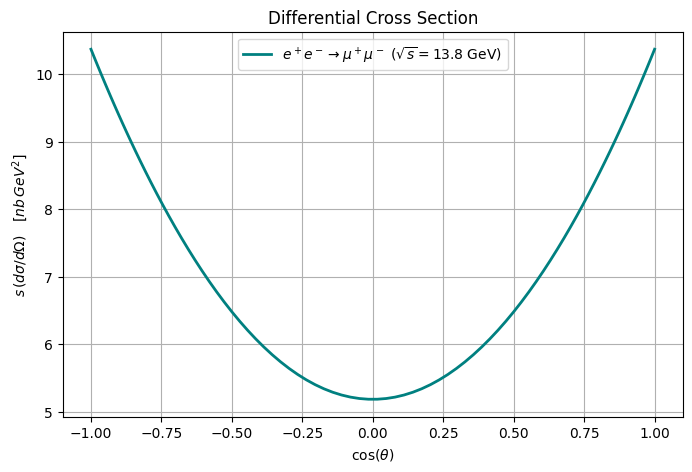

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from Kinematics import  kinematics2To2

plt.style.use('seaborn-v0_8-muted') 
plt.rcParams['axes.grid'] = True


# Capture 
py_expr = capture_physics_expr("scripts/ee_to_mumu_noM.txt")
print(f"Captured Expression: {py_expr}")

#Inputs
sqrtS = 13.8
alpha = 1/137.036
# Conversion Factors from Natural Units to Cross-Section 
# (0.197327 GeV * fm)^2 = 0.0389379 GeV^2 * fm^2
# 1 GeV^-2 = 0.389379 mb (millibarns)
conv_gev2_to_nb = 389379.0

# Fill values for Plotting
angles = np.linspace(0, np.pi, 100)
x_vals = np.cos(angles)
s_val, t_vals, u_vals, ratio_val = kinematics2To2(sqrtS, angles)
y_vals = eval(py_expr, {
    "s": s_val, 
    "t": t_vals, 
    "u": u_vals, 
    "alpha": alpha,
    "pfInOutRatio" : ratio_val
})
y_vals = (sqrtS**2) * y_vals * conv_gev2_to_nb


# Plot
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, lw=2, color='teal', label=rf'$e^+e^- \to \mu^+\mu^-$ ($\sqrt{{s}}={(sqrtS)}$ GeV)')
plt.title("Differential Cross Section")
plt.xlabel(r"$\cos(\theta)$")
plt.ylabel(r"$s\, (d\sigma/d\Omega)\quad [nb\, GeV^2]$ ")
plt.legend()
plt.show()
    
